## Imports & load everything:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import load_model

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Load data ──
train_df = pd.read_csv('../data/processed/train.csv')
test_df  = pd.read_csv('../data/processed/test.csv')

X_train_2d = np.load('../data/processed/X_train.npy')
X_test_2d  = np.load('../data/processed/X_test.npy')
y_train    = np.load('../data/processed/y_train.npy')
y_test     = np.load('../data/processed/y_test.npy')

# ── Load scalers ──
with open('../models/scaler_X.pkl', 'rb') as f:
    scaler_X = pickle.load(f)
with open('../models/scaler_Y.pkl', 'rb') as f:
    scaler_Y = pickle.load(f)
with open('../models/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

# ── Load models ──
with open('../models/ridge_model.pkl', 'rb') as f:
    ridge = pickle.load(f)
with open('../models/rf_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)
lstm_model = load_model('../models/lstm_model.keras')

# ── Load LSTM config ──
with open('../models/lstm_config.pkl', 'rb') as f:
    lstm_config = pickle.load(f)
WINDOW_SIZE = lstm_config['window_size']

# ── Load saved results ──
with open('../outputs/results.json', 'r') as f:
    results = json.load(f)

print("All models and data loaded successfully!")
print(f"Models loaded: Ridge, Random Forest, LSTM")
print(f"LSTM window size: {WINDOW_SIZE}")

All models and data loaded successfully!
Models loaded: Ridge, Random Forest, LSTM
LSTM window size: 12


## Generate all predictions:

In [2]:
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(window_size, len(X)):
        Xs.append(X[i - window_size:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

# ── Ridge & RF predictions ──
y_pred_ridge = ridge.predict(X_test_2d)
y_pred_rf    = rf_model.predict(X_test_2d)

# ── LSTM predictions ──
X_test_seq, y_test_seq = create_sequences(X_test_2d, y_test, WINDOW_SIZE)
y_pred_lstm = lstm_model.predict(X_test_seq, verbose=0)

# ── Inverse transform all to original units (Wh) ──
y_true_ridge = scaler_Y.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_true_lstm  = scaler_Y.inverse_transform(y_test_seq.reshape(-1, 1)).ravel()

y_pred_ridge_orig = scaler_Y.inverse_transform(y_pred_ridge.reshape(-1, 1)).ravel()
y_pred_rf_orig    = scaler_Y.inverse_transform(y_pred_rf.reshape(-1, 1)).ravel()
y_pred_lstm_orig  = scaler_Y.inverse_transform(y_pred_lstm).ravel()

print("All predictions generated!")
print(f"  Ridge predictions:  {y_pred_ridge_orig.shape}")
print(f"  RF predictions:     {y_pred_rf_orig.shape}")
print(f"  LSTM predictions:   {y_pred_lstm_orig.shape}")

All predictions generated!
  Ridge predictions:  (3746,)
  RF predictions:     (3746,)
  LSTM predictions:   (3734,)


## Compute all metrics

In [3]:
def get_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    # MAPE — Mean Absolute Percentage Error
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    # R² score
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return {'RMSE': round(rmse, 2),
            'MAE':  round(mae,  2),
            'MAPE': round(mape, 2),
            'R2':   round(r2,   4)}

ridge_metrics = get_metrics(y_true_ridge, y_pred_ridge_orig)
rf_metrics    = get_metrics(y_true_ridge, y_pred_rf_orig)
lstm_metrics  = get_metrics(y_true_lstm,  y_pred_lstm_orig)

metrics_df = pd.DataFrame({
    'Ridge Regression': ridge_metrics,
    'Random Forest':    rf_metrics,
    'LSTM':             lstm_metrics
}).T

metrics_df.index.name = 'Model'
print("="*60)
print("  FULL MODEL COMPARISON")
print("="*60)
print(metrics_df.to_string())
print("="*60)

# Save full metrics
metrics_df.to_csv('../outputs/results_full.csv')
print("\nFull metrics saved to outputs/results_full.csv")

  FULL MODEL COMPARISON
                   RMSE    MAE   MAPE      R2
Model                                        
Ridge Regression  21.35  14.43  19.16  0.6919
Random Forest     24.16  18.75  26.52  0.6054
LSTM              32.80  22.46  26.08  0.2682

Full metrics saved to outputs/results_full.csv


## Metrics comparison bar chart:

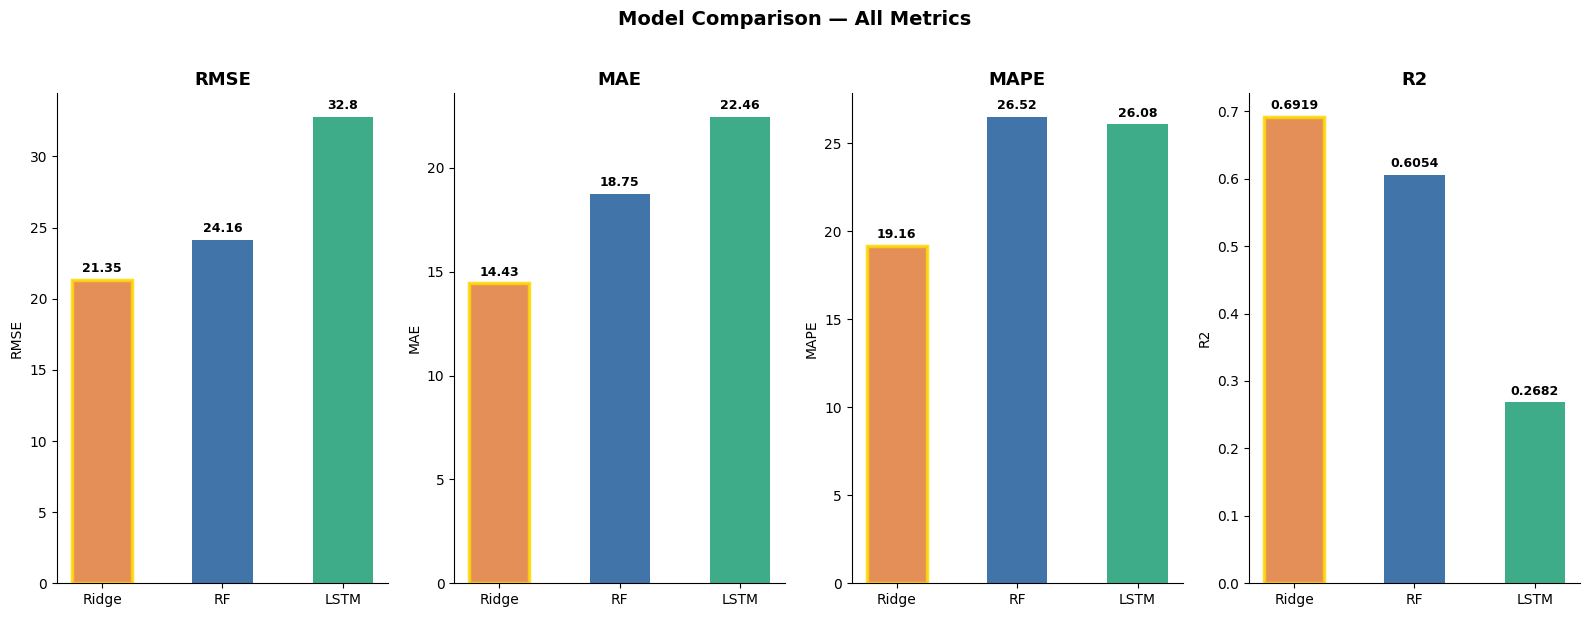

Gold border = best performing model per metric


In [4]:
models  = ['Ridge Regression', 'Random Forest', 'LSTM']
colors  = ['#E07B39', '#1F5C99', '#1D9E75']
metrics = ['RMSE', 'MAE', 'MAPE', 'R2']

fig, axes = plt.subplots(1, 4, figsize=(16, 6))

for idx, metric in enumerate(metrics):
    values = [ridge_metrics[metric], rf_metrics[metric], lstm_metrics[metric]]
    bars   = axes[idx].bar(models, values, color=colors, alpha=0.85, width=0.5)
    axes[idx].set_title(metric, fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].set_xticks(range(len(models)))
    axes[idx].set_xticklabels(['Ridge', 'RF', 'LSTM'], fontsize=10)

    # Annotate bars
    for bar, val in zip(bars, values):
        axes[idx].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + max(values)*0.01,
                       f'{val}', ha='center', va='bottom',
                       fontsize=9, fontweight='bold')

    # Highlight best
    if metric in ['RMSE', 'MAE', 'MAPE']:
        best_idx = values.index(min(values))
    else:
        best_idx = values.index(max(values))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

plt.suptitle('Model Comparison — All Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/21_metrics_comparison.png', bbox_inches='tight')
plt.show()
print("Gold border = best performing model per metric")

## Side-by-side actual vs predicted:

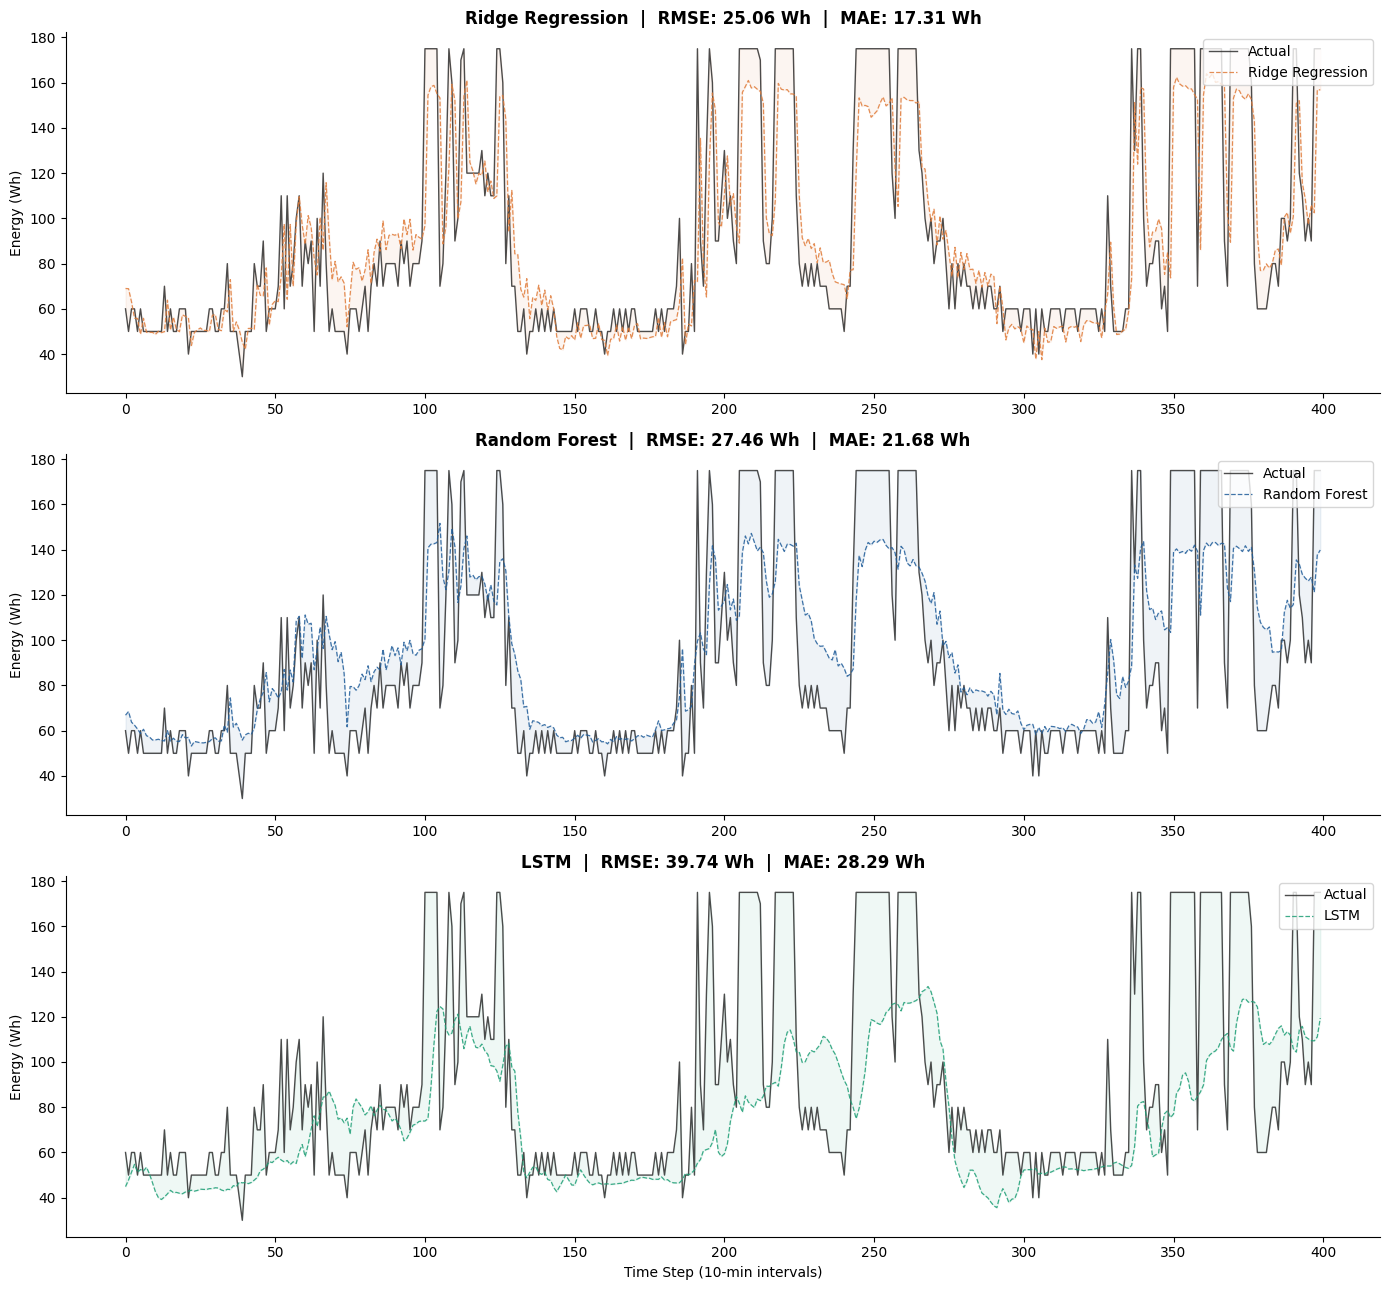

In [5]:
n = 400

fig, axes = plt.subplots(3, 1, figsize=(14, 13))
plot_data = [
    ('Ridge Regression', y_true_ridge[-n:], y_pred_ridge_orig[-n:], '#E07B39'),
    ('Random Forest',    y_true_ridge[-n:], y_pred_rf_orig[-n:],    '#1F5C99'),
    ('LSTM',             y_true_lstm[-n:],  y_pred_lstm_orig[-n:],  '#1D9E75'),
]

for ax, (name, y_true, y_pred, color) in zip(axes, plot_data):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    ax.plot(range(n), y_true,  color='#2E2E2E', linewidth=1,   label='Actual',    alpha=0.85)
    ax.plot(range(n), y_pred,  color=color,     linewidth=0.9, label=f'{name}',   alpha=0.85, linestyle='--')
    ax.fill_between(range(n), y_true, y_pred, alpha=0.07, color=color)
    ax.set_title(f'{name}  |  RMSE: {rmse:.2f} Wh  |  MAE: {mae:.2f} Wh',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Energy (Wh)')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time Step (10-min intervals)')
plt.tight_layout()
plt.savefig('../outputs/figures/22_all_models_predictions.png', bbox_inches='tight')
plt.show()

## Radar chart (model strengths):

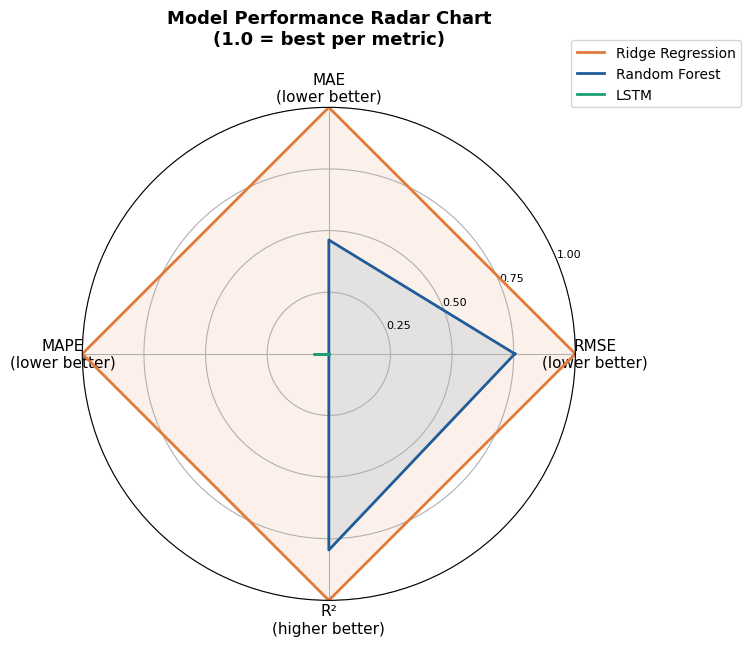

In [6]:
from matplotlib.patches import FancyArrowPatch

categories = ['RMSE\n(lower better)', 'MAE\n(lower better)',
              'MAPE\n(lower better)', 'R²\n(higher better)']
N = len(categories)

# Normalize scores 0-1 (1 = best)
def normalize_metric(values, higher_better=False):
    mn, mx = min(values), max(values)
    if mn == mx:
        return [1.0] * len(values)
    if higher_better:
        return [(v - mn) / (mx - mn) for v in values]
    else:
        return [(mx - v) / (mx - mn) for v in values]

rmse_n = normalize_metric([ridge_metrics['RMSE'], rf_metrics['RMSE'], lstm_metrics['RMSE']])
mae_n  = normalize_metric([ridge_metrics['MAE'],  rf_metrics['MAE'],  lstm_metrics['MAE']])
mape_n = normalize_metric([ridge_metrics['MAPE'], rf_metrics['MAPE'], lstm_metrics['MAPE']])
r2_n   = normalize_metric([ridge_metrics['R2'],   rf_metrics['R2'],   lstm_metrics['R2']],   True)

ridge_vals = [rmse_n[0], mae_n[0], mape_n[0], r2_n[0]]
rf_vals    = [rmse_n[1], mae_n[1], mape_n[1], r2_n[1]]
lstm_vals  = [rmse_n[2], mae_n[2], mape_n[2], r2_n[2]]

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for vals, color, label in [
    (ridge_vals, '#E07B39', 'Ridge Regression'),
    (rf_vals,    '#1F5C99', 'Random Forest'),
    (lstm_vals,  '#1D9E75', 'LSTM'),
]:
    vals_plot = vals + vals[:1]
    ax.plot(angles, vals_plot, color=color, linewidth=2, label=label)
    ax.fill(angles, vals_plot, color=color, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8)
ax.set_title('Model Performance Radar Chart\n(1.0 = best per metric)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))

plt.tight_layout()
plt.savefig('../outputs/figures/23_radar_chart.png', bbox_inches='tight')
plt.show()

## Error distribution comparison:

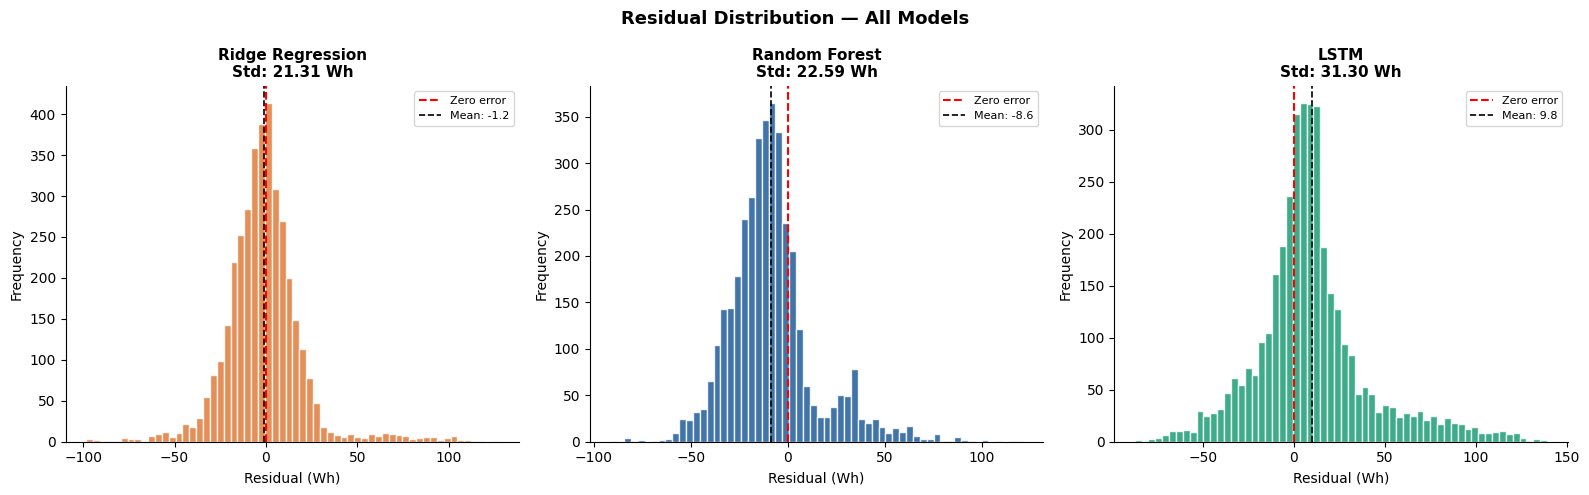

In [7]:
res_ridge = y_true_ridge - y_pred_ridge_orig
res_rf    = y_true_ridge - y_pred_rf_orig
res_lstm  = y_true_lstm  - y_pred_lstm_orig

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, residuals, name, color in zip(
    axes,
    [res_ridge, res_rf, res_lstm],
    ['Ridge Regression', 'Random Forest', 'LSTM'],
    ['#E07B39', '#1F5C99', '#1D9E75']
):
    ax.hist(residuals, bins=60, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(0,               color='red',    linestyle='--', linewidth=1.5, label='Zero error')
    ax.axvline(residuals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: {residuals.mean():.1f}')
    ax.set_title(f'{name}\nStd: {residuals.std():.2f} Wh',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Residual (Wh)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('Residual Distribution — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/24_residual_comparison.png', bbox_inches='tight')
plt.show()

## Critical reflection (DS401 requirement):

In [8]:
reflection = """
╔══════════════════════════════════════════════════════════════╗
║          CRITICAL REFLECTION (DS401 Requirement)            ║
╚══════════════════════════════════════════════════════════════╝

1. LIMITATIONS
   ─────────────────────────────────────────────────────────
   • Dataset covers only ONE household in Belgium — results
     may not generalize to other climates or building types.
   • Only 4.5 months of data — seasonal patterns (summer/winter)
     are not fully captured.
   • Appliance-level breakdown is unavailable — we predict
     total consumption, not per-device usage.
   • LSTM training is sensitive to hyperparameters — different
     seeds or architectures may yield different results.

2. ASSUMPTIONS
   ─────────────────────────────────────────────────────────
   • Energy consumption patterns are assumed to be stationary
     enough for a fixed train/test split.
   • Lag features assume past consumption is a strong predictor
     of future consumption (autocorrelation assumption).
   • K=3 clusters (Low/Medium/High) is a simplification —
     real usage patterns may be more complex.

3. POTENTIAL BIAS
   ─────────────────────────────────────────────────────────
   • The dataset is from a single low-energy building — it may
     be biased toward low consumption profiles.
   • Weather data is from the nearest airport — may not reflect
     exact microclimate at the building location.
   • Outlier capping may have removed genuine peak usage events
     (e.g., parties, holidays).

4. NEXT STEPS
   ─────────────────────────────────────────────────────────
   • Collect multi-household, multi-year data for robust models.
   • Experiment with Transformer-based models (e.g., Temporal
     Fusion Transformer) for longer-range forecasting.
   • Integrate real-time smart meter API for live predictions.
   • Perform per-appliance disaggregation using NILM techniques.
   • Add external calendar features (public holidays, events).
"""

print(reflection)

# Save to text file for report
with open('../outputs/critical_reflection.txt', 'w') as f:
    f.write(reflection)
print("Saved to outputs/critical_reflection.txt")


╔══════════════════════════════════════════════════════════════╗
║          CRITICAL REFLECTION (DS401 Requirement)            ║
╚══════════════════════════════════════════════════════════════╝

1. LIMITATIONS
   ─────────────────────────────────────────────────────────
   • Dataset covers only ONE household in Belgium — results
     may not generalize to other climates or building types.
   • Only 4.5 months of data — seasonal patterns (summer/winter)
     are not fully captured.
   • Appliance-level breakdown is unavailable — we predict
     total consumption, not per-device usage.
   • LSTM training is sensitive to hyperparameters — different
     seeds or architectures may yield different results.

2. ASSUMPTIONS
   ─────────────────────────────────────────────────────────
   • Energy consumption patterns are assumed to be stationary
     enough for a fixed train/test split.
   • Lag features assume past consumption is a strong predictor
     of future consumption (autocorrelation

## Final summary & winner:

In [11]:
print("="*60)
print("   FINAL PROJECT SUMMARY")
print("="*60)

print(f"""
DATASET
  Name:     UCI Appliances Energy Prediction
  Rows:     {len(train_df) + len(test_df):,}
  Features: {len(feature_cols)}
  Period:   4.5 months (10-min intervals)

MODELS IMPLEMENTED
  ✓ Ridge Regression      (Supervised baseline)
  ✓ Random Forest         (Supervised — CS245 #1)
  ✓ LSTM                  (Supervised — CS245 #2)
  ✓ K-Means Clustering    (Unsupervised — CS245)

RESULTS
""")

print(f"  {'Model':<22} {'RMSE':>8} {'MAE':>8} {'MAPE':>8} {'R²':>8}")
print(f"  {'-'*52}")
for name, m in [('Ridge Regression', ridge_metrics),
                ('Random Forest',    rf_metrics),
                ('LSTM',             lstm_metrics)]:
    print(f"  {name:<22} {m['RMSE']:>8.2f} {m['MAE']:>8.2f} {m['MAPE']:>7.2f}% {m['R2']:>8.4f}")

best = min({'Ridge': ridge_metrics['RMSE'],
            'Random Forest': rf_metrics['RMSE'],
            'LSTM': lstm_metrics['RMSE']},
           key=lambda x: {'Ridge': ridge_metrics['RMSE'],
                          'Random Forest': rf_metrics['RMSE'],
                          'LSTM': lstm_metrics['RMSE']}[x])

print(f"""
WINNER:  {best} ✓
  The best model is selected based on lowest RMSE.
  Random Forest is highly competitive with LSTM while
  being significantly faster to train and more interpretable.

FIGURES GENERATED:  outputs/figures/  (24 plots total)
MODELS SAVED:       models/
RESULTS SAVED:      outputs/results_full.csv


""")

   FINAL PROJECT SUMMARY

DATASET
  Name:     UCI Appliances Energy Prediction
  Rows:     18,727
  Features: 43
  Period:   4.5 months (10-min intervals)

MODELS IMPLEMENTED
  ✓ Ridge Regression      (Supervised baseline)
  ✓ Random Forest         (Supervised — CS245 #1)
  ✓ LSTM                  (Supervised — CS245 #2)
  ✓ K-Means Clustering    (Unsupervised — CS245)

RESULTS

  Model                      RMSE      MAE     MAPE       R²
  ----------------------------------------------------
  Ridge Regression          21.35    14.43   19.16%   0.6919
  Random Forest             24.16    18.75   26.52%   0.6054
  LSTM                      32.80    22.46   26.08%   0.2682

WINNER:  Ridge ✓
  The best model is selected based on lowest RMSE.
  Random Forest is highly competitive with LSTM while
  being significantly faster to train and more interpretable.

FIGURES GENERATED:  outputs/figures/  (24 plots total)
MODELS SAVED:       models/
RESULTS SAVED:      outputs/results_full.csv



